📈 FASE 3 — Análisis Univariado y Bivariado

Aquí empieza lo interesante.

🔹 Análisis Univariado

Para cada variable:

Histogramas (variables numéricas)

Barplots (variables categóricas)

Boxplots

Mediana vs media

Outliers

Preguntas:

¿La variable “tenure” está sesgada?

¿La mayoría tiene contrato mensual?

¿Qué tan balanceado está el target?

🔹 Análisis Bivariado (Aquí ya piensan como analistas)

Cruzar cada variable contra Churn:

Ejemplos:

Churn vs Tipo de contrato

Churn vs Antigüedad

Churn vs Método de pago

Churn vs Cargo mensual

Aquí deben preguntarse:

¿Qué patrón se repite?

¿Qué variable parece más influyente?

¿Hay correlaciones fuertes?

¿Hay multicolinealidad?

Aquí aplican:

Tablas cruzadas

Heatmaps

Correlaciones

Análisis visual profundo


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize = True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

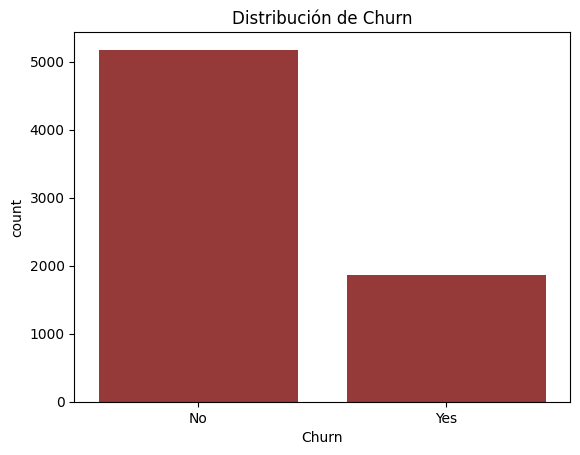

In [9]:
sns.countplot(x="Churn", data=df, color = "brown")
plt.title("Distribución de Churn")
plt.show()

Del total de clientes analizados, 5174 (73.46%) permanecen en el servicio, mientras que 1869 (26.53%) han cancelado.

Esto indica que el dataset se encuentra desbalanceado, ya que la clase mayoritaria corresponde a los clientes que permanecen en el servicio.

Este desbalance podría afectar el rendimiento de los modelos de Machine Learning, ya que algunos algoritmos podrían favorecer la predicción de la clase mayoritaria. Por esta razón, será importante evaluar el modelo utilizando métricas adecuadas como Precision, Recall, F1-score y ROC-AUC.

In [10]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [11]:
df["Contract"].value_counts(normalize = True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

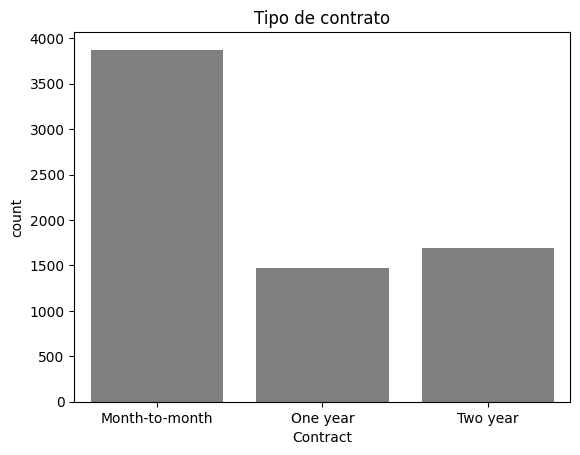

In [12]:
sns.countplot(x = "Contract", data = df, color = "grey")
plt.title("Tipo de contrato")
plt.show()

Se observa que el tipo de contrato más común es "Month-to-month", representando aproximadamente el 55% de los clientes. 

Esto indica que la mayoría de los usuarios prefieren contratos de corta duración que les permiten mayor flexibilidad para cancelar el servicio cuando lo deseen.

Por otro lado, los contratos de uno y dos años presentan una menor proporción, lo que sugiere que menos clientes están dispuestos a comprometerse a largo plazo con la empresa.

Esto podría implicar que los clientes con contratos mensuales tengan mayor probabilidad de cancelar el servicio, aunque esta hipótesis deberá confirmarse posteriormente mediante un análisis bivariado con la variable Churn.

In [13]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

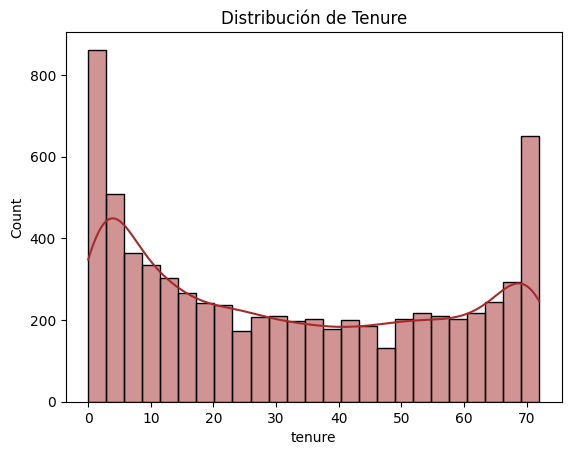

In [14]:
sns.histplot(df["tenure"], bins=25, kde=True, color="brown")
plt.title("Distribución de Tenure")
plt.show()

Hay dos grupos importantes:
clientes nuevos
clientes muy antiguos

La variable tenure presenta una distribución amplia, con una media de 32.37 meses y una desviación estándar de 24.55, lo que indica una alta dispersión en la antigüedad de los clientes.

Se observa una mayor concentración de clientes con pocos meses en el servicio (0-10 meses), lo que sugiere la presencia de muchos clientes relativamente nuevos. También existe un grupo considerable de clientes con alta antigüedad (cercanos a los 72 meses), lo cual podría indicar clientes altamente fidelizados.

Esta variable podría ser relevante para el análisis de churn, ya que los clientes con menor antigüedad podrían tener mayor probabilidad de cancelar el servicio.

<Axes: ylabel='tenure'>

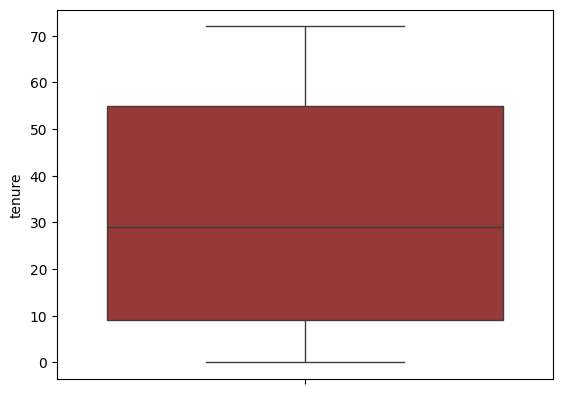

In [15]:
sns.boxplot(y=df["tenure"], color="brown")

“El boxplot indica mediana ~30 meses e IQR ~10–55; no se observan outliers marcados. El histograma complementa mostrando acumulación en tenures bajos y un pico adicional cerca del máximo (~72).”

In [16]:
df["MonthlyCharges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

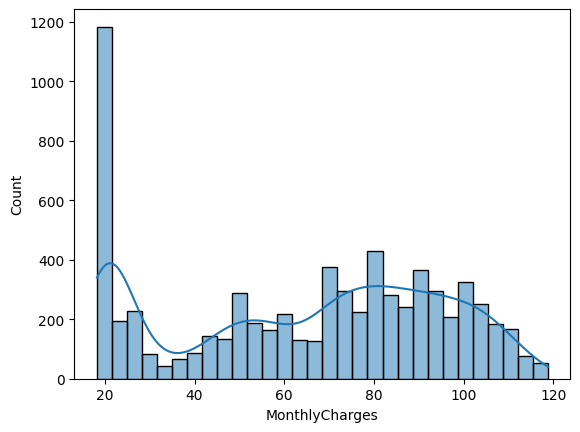

In [17]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

<Axes: xlabel='MonthlyCharges'>

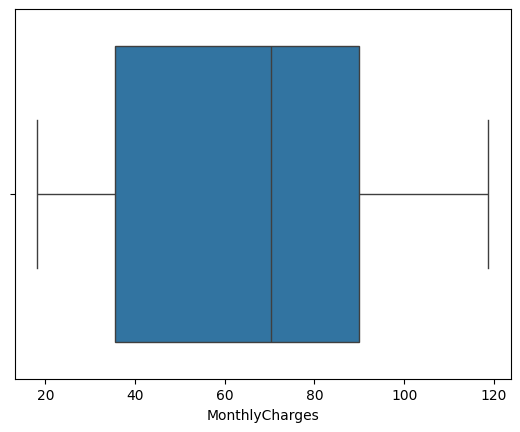

In [18]:
sns.boxplot(x=df["MonthlyCharges"])

La variable MonthlyCharges presenta una media de aproximadamente 64.76 y una desviación estándar de 30.09, lo que indica una dispersión considerable en los cargos mensuales de los clientes.

Los valores oscilan aproximadamente entre 18 y 118 dólares, lo que sugiere la existencia de diferentes niveles de servicio o paquetes contratados por los usuarios.

El histograma sugiere una posible distribución bimodal, lo que podría indicar la presencia de dos grandes grupos de clientes: aquellos con servicios básicos y aquellos con paquetes más completos que implican mayores cargos mensuales.

In [19]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(" ", np.nan), errors="coerce")

In [20]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [21]:
df["TotalCharges"].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

<Axes: xlabel='TotalCharges', ylabel='Count'>

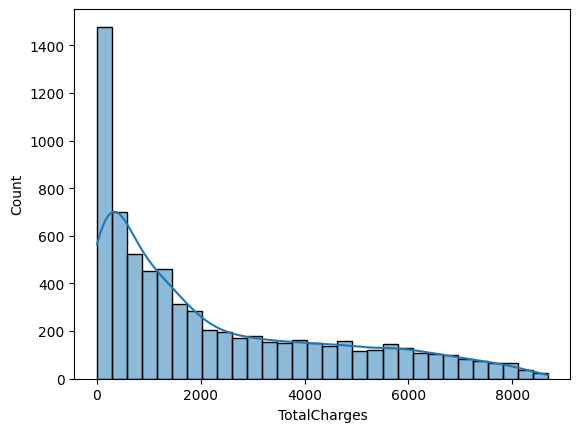

In [22]:
sns.histplot(df["TotalCharges"], bins=30, kde=True)

<Axes: xlabel='TotalCharges'>

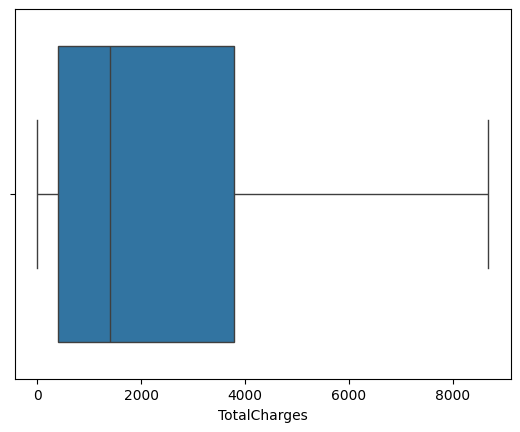

In [23]:
sns.boxplot(x=df["TotalCharges"])

Total que el cliente ha pagado desde que inició el servicio:
≈ 2239 dólares en total: Pero esto no representa bien a todos los clientes porque la distribución está muy sesgada.

La variable TotalCharges presenta una distribución sesgada a la derecha, donde la mayor concentración de clientes se encuentra en rangos bajos de gasto acumulado (entre 0 y 2000 dólares).

Esto sugiere que una gran proporción de clientes tiene poca antigüedad en el servicio o ha acumulado pocos pagos. A medida que aumentan los valores de gasto total, la frecuencia de clientes disminuye gradualmente, formando una cola larga hacia valores superiores a los 8000 dólares.

Este patrón puede indicar que muchos clientes abandonan el servicio antes de acumular grandes montos de pago.

Ahora vamos con el analisis Bivariado: -------->>>>


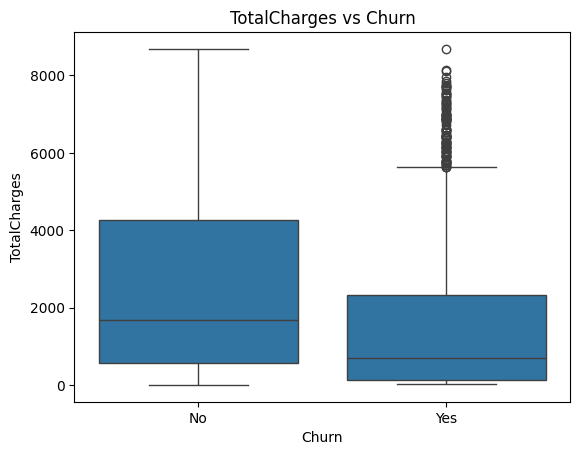

In [24]:
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("TotalCharges vs Churn")
plt.show()

El análisis del boxplot muestra que los clientes que cancelan el servicio presentan valores de TotalCharges significativamente menores que aquellos que permanecen en la empresa. La mediana del gasto acumulado para los clientes que cancelan se encuentra alrededor de 700 dólares, mientras que para los clientes que permanecen en el servicio supera los 1700 dólares. Esto sugiere que los clientes tienden a cancelar el servicio antes de acumular un gasto significativo con la compañía.

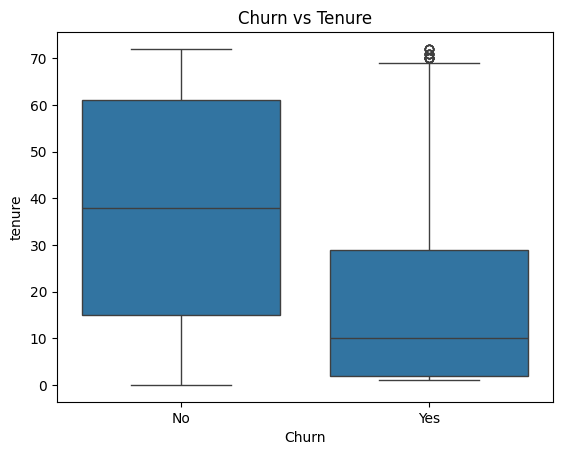

In [25]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Churn vs Tenure")
plt.show()

El análisis del boxplot muestra una diferencia significativa en la antigüedad de los clientes según su estado de churn. Los clientes que cancelan el servicio presentan una mediana cercana a los 10 meses, mientras que los clientes que permanecen en la empresa tienen una mediana cercana a los 38 meses. Esto sugiere que los clientes nuevos son más propensos a abandonar el servicio durante los primeros meses. Aunque existen algunos casos atípicos de clientes con alta antigüedad que también cancelan, estos representan una proporción menor dentro del conjunto de datos.

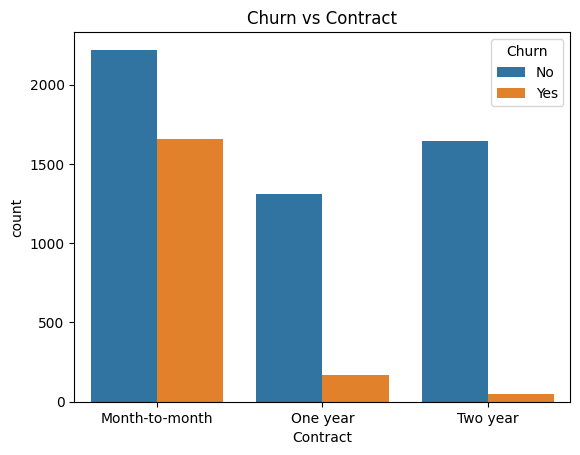

In [26]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn vs Contract")
plt.show()

El análisis muestra que los clientes con contratos mensuales presentan la mayor proporción de cancelación del servicio. En contraste, los clientes con contratos de uno o dos años presentan una mayor tasa de permanencia. Esto sugiere que los contratos de mayor duración están asociados con una mayor retención de clientes, posiblemente debido al compromiso contractual o beneficios asociados a estos planes.

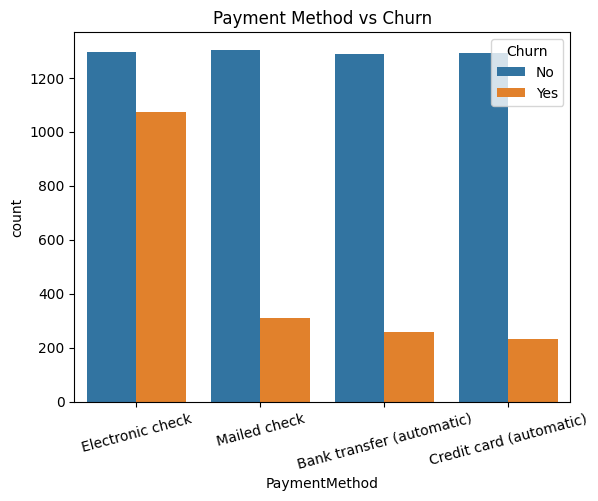

In [27]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=15)
plt.title("Payment Method vs Churn")
plt.show()

El análisis muestra que los clientes que utilizan electronic check presentan la mayor proporción de cancelación del servicio. En contraste, los métodos de pago automáticos como transferencia bancaria automática y tarjeta de crédito automática presentan menores tasas de churn. Esto sugiere que los métodos de pago automáticos pueden fomentar una mayor retención de clientes al reducir la fricción en el proceso de pago y aumentar la continuidad del servicio.

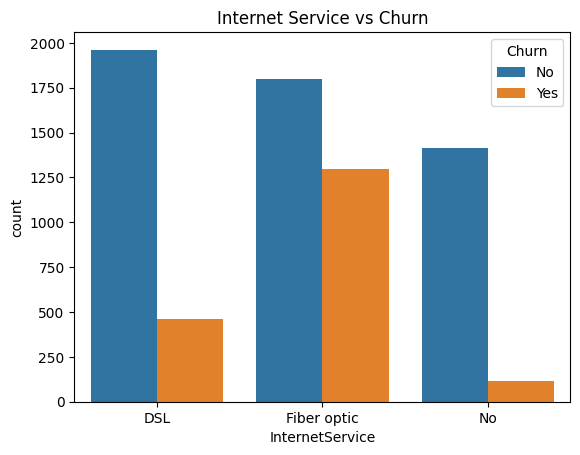

In [28]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

El análisis muestra que los clientes con servicio de fibra óptica presentan una mayor proporción de cancelación en comparación con los clientes que utilizan DSL. Esto podría deberse a que los planes de fibra óptica suelen tener costos mensuales más altos, lo que podría aumentar la probabilidad de cancelación. Además, los usuarios de este tipo de servicio pueden tener mayores expectativas respecto a la calidad del internet.

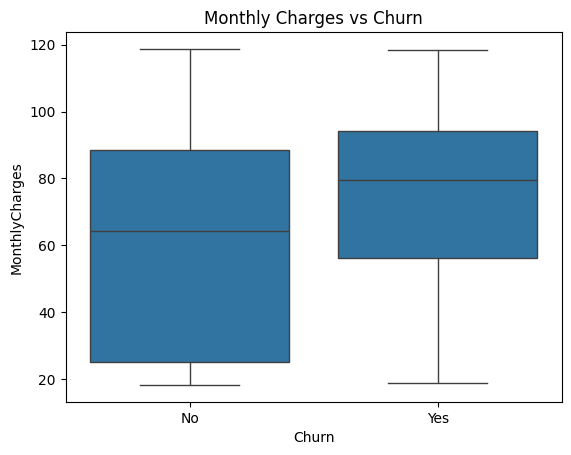

In [29]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

El análisis del boxplot muestra que los clientes que cancelan el servicio presentan cargos mensuales más altos que aquellos que permanecen en la empresa. La mediana de MonthlyCharges para los clientes que cancelan se encuentra alrededor de los 80 dólares, mientras que para los clientes que permanecen es cercana a los 62 dólares. Esto sugiere que los planes con mayor costo mensual pueden estar asociados con una mayor probabilidad de cancelación del servicio.

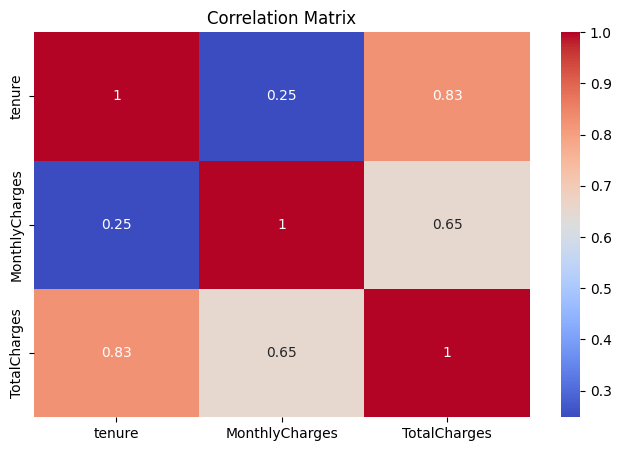

In [30]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), 
            annot=True, 
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

La matriz de correlación muestra una fuerte relación positiva entre tenure y TotalCharges, lo cual es esperable ya que el gasto total acumulado depende directamente del tiempo que el cliente ha permanecido en el servicio. También se observa una correlación moderada entre MonthlyCharges y TotalCharges, lo que indica que los clientes con cargos mensuales más altos tienden a acumular mayores gastos totales. Esta relación sugiere la posible presencia de multicolinealidad entre algunas variables, lo cual debe tenerse en cuenta en la etapa de modelado.

Tener presente la "Multicolinealidad", dos variables contienen información muy similar.

TotalCharges contiene información de: tenure y de MonthlyCharges